# LOADING THE DATASET

In [1]:
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt

import os

pollution_df = pd.read_csv('/kaggle/input/datasets/jakovlovakovic/pollutiondataset/pollutionData.csv')

import kagglehub

In [2]:
print(pollution_df.head(5))
print(pollution_df.columns)
pollution_df.index

   PM10Lehen  NOXLehen  RFLehen  LTLehen  O3Lehen  PM10Rud  MOXRud  RPRud  \
0      642.2      77.4     83.0      0.1      2.0    251.8    67.0   81.0   
1      336.1      47.4     81.0      0.3      2.0    244.2   133.8   78.0   
2      242.7      42.5     80.0      0.2      2.0    282.3   145.9   81.0   
3      201.1      41.1     82.0     -0.3      2.0    362.4   177.1   79.0   
4      165.7      38.2     83.0     -0.5      2.0    281.0   116.7   77.0   

   LTRud  CORud   WG     WT   GS  
0    0.7   0.60  2.7  153.0  5.0  
1    0.9   0.77  3.7  156.0  5.0  
2    0.2   0.89  2.9  166.0  4.0  
3    0.7   0.77  2.5  137.0  4.0  
4    0.6   0.62  1.8  144.0  4.0  
Index(['PM10Lehen', 'NOXLehen', 'RFLehen', 'LTLehen', 'O3Lehen', 'PM10Rud',
       'MOXRud', 'RPRud', 'LTRud', 'CORud', 'WG', 'WT', 'GS'],
      dtype='object')


RangeIndex(start=0, stop=17520, step=1)

# WF2 Gathering data: recommendation system

In this first step I will redo the analysis as it is on the webpage and comment on each step

# a) Reading the data

In [3]:
import os
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        print(os.path.join(root, f))

/kaggle/input/datasets/jakovlovakovic/pollutiondataset/pollutionData.csv
/kaggle/input/datasets/jakovlovakovic/movies/movies.csv
/kaggle/input/datasets/jakovlovakovic/movies/ratings.csv
/kaggle/input/datasets/jakovlovakovic/movies/tags.csv
/kaggle/input/datasets/jakovlovakovic/movies/links.csv


In [4]:
path = '/kaggle/input/datasets/jakovlovakovic/movies/'
ratings_path = path + 'ratings.csv'
movies_path = path + 'movies.csv'
tags_path = path + 'tags.csv'

movie_data = pd.read_csv(ratings_path)

movies = pd.read_csv(movies_path)

tags=pd.read_csv(tags_path)

In [5]:
movie_data.head(10)

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931
5,1,70,3.0,964982400
6,1,101,5.0,964980868
7,1,110,4.0,964982176
8,1,151,5.0,964984041
9,1,157,5.0,964984100


In [6]:
movies.head(10)

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
5,6,Heat (1995),Action|Crime|Thriller
6,7,Sabrina (1995),Comedy|Romance
7,8,Tom and Huck (1995),Adventure|Children
8,9,Sudden Death (1995),Action
9,10,GoldenEye (1995),Action|Adventure|Thriller


In [7]:
tags=tags[['movieId','tag']]
tags.head(10)

,movieId,tag
0,60756,funny
1,60756,Highly quotable
2,60756,will ferrell
3,89774,Boxing story
4,89774,MMA
5,89774,Tom Hardy
6,106782,drugs
7,106782,Leonardo DiCaprio
8,106782,Martin Scorsese
9,48516,way too long


# b) Merging the dataset

In [8]:
movie_data=movie_data.merge(movies,on='movieId',how='left')
movie_data=movie_data.merge(tags,on='movieId',how='left')
movie_data.head(10)

,userId,movieId,rating,timestamp,title,genres,tag
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,pixar
1,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,pixar
2,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,fun
3,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance,moldy
4,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance,old
5,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller,NaN
6,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,mystery
7,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,twist ending
8,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,serial killer
9,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,mindfuck


# c) Average the rating of each movie

In [9]:
rating = pd.DataFrame(movie_data.groupby('title')['rating'].mean())
rating.head(10)

,rating
title,
'71 (2014),4.000000
'Hellboy': The Seeds of Creation (2004),4.000000
'Round Midnight (1986),3.500000
'Salem's Lot (2004),5.000000
'Til There Was You (1997),4.000000
'Tis the Season for Love (2015),1.500000
"'burbs, The (1989)",3.176471
'night Mother (1986),3.000000
(500) Days of Summer (2009),3.666667


# d) Total number of ratings given to each movie

In [10]:
rating['Total Rating']=pd.DataFrame(movie_data.groupby('title')['rating'].count())
rating.head(10)

,rating,Total Rating
title,,
'71 (2014),4.000000,1
'Hellboy': The Seeds of Creation (2004),4.000000,1
'Round Midnight (1986),3.500000,2
'Salem's Lot (2004),5.000000,1
'Til There Was You (1997),4.000000,2
'Tis the Season for Love (2015),1.500000,1
"'burbs, The (1989)",3.176471,17
'night Mother (1986),3.000000,1
(500) Days of Summer (2009),3.666667,336


# e) Correlation between the data

In [11]:
movie_user=movie_data.pivot_table(index='userId',columns='title',values='rating')
movie_user.head(10)

title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Round Midnight (1986),'Salem's Lot (2004),'Til There Was You (1997),'Tis the Season for Love (2015),"'burbs, The (1989)",'night Mother (1986),(500) Days of Summer (2009),*batteries not included (1987),...,Zulu (2013),[REC] (2007),[REC]² (2009),[REC]³ 3 Génesis (2012),anohana: The Flower We Saw That Day - The Movie (2013),eXistenZ (1999),xXx (2002),xXx: State of the Union (2005),¡Three Amigos! (1986),À nous la liberté (Freedom for Us) (1931)
userId,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN


# f) Choosing the movie

In [12]:
movie_name = 'Iron Man (2008)'
correlation=movie_user.corrwith(movie_user[movie_name])
correlation.head(10)

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


title
'71 (2014)                                      NaN
'Hellboy': The Seeds of Creation (2004)         NaN
'Round Midnight (1986)                          NaN
'Salem's Lot (2004)                             NaN
'Til There Was You (1997)                       NaN
'Tis the Season for Love (2015)                 NaN
'burbs, The (1989)                         0.456543
'night Mother (1986)                            NaN
(500) Days of Summer (2009)                0.611279
*batteries not included (1987)             0.271448
dtype: float64

# g) Removing all empty values

In [13]:
recommandation=pd.DataFrame(correlation,columns=['correlation'])
recommandation.dropna(inplace=True)
recommandation=recommandation.join(rating['Total Rating'])
recommandation.head()

,correlation,Total Rating
title,,
"'burbs, The (1989)",0.456543,17
(500) Days of Summer (2009),0.611279,336
*batteries not included (1987),0.271448,7
10 Cloverfield Lane (2016),-0.206733,28
10 Things I Hate About You (1999),-0.264545,54


# h) Select movie with at least 150 ratings

In [14]:
recc=recommandation[recommandation['Total Rating']>150].sort_values('correlation',ascending=False).reset_index()
recc=recc.merge(movies,on='title',how='left')
recc.head(10)

,title,correlation,Total Rating,movieId,genres
0,Avengers: Infinity War - Part I (2018),0.764922,195,122912,Action|Adventure|Sci-Fi
1,Whiplash (2014),0.711657,342,112552,Drama
2,Star Trek (2009),0.687861,531,68358,Action|Adventure|Sci-Fi|IMAX
3,"Avengers, The (2012)",0.684344,483,89745,Action|Adventure|Sci-Fi|IMAX
4,Ratatouille (2007),0.657183,288,50872,Animation|Children|Drama
5,Terminator Salvation (2009),0.619493,216,68791,Action|Adventure|Sci-Fi|Thriller
6,(500) Days of Summer (2009),0.611279,336,69757,Comedy|Drama|Romance
7,X2: X-Men United (2003),0.609979,380,6333,Action|Adventure|Sci-Fi|Thriller
8,X-Men (2000),0.583925,798,3793,Action|Adventure|Sci-Fi
9,Burn After Reading (2008),0.564151,429,61323,Comedy|Crime|Drama


# i) Analysis

The first issue in the analysis is incorrect merging. We can see that by the output of the bottom cell. Problem is merging with ratings and tags. A movie can have many ratings and many tags. Merging on movieId pairs every rating with every tag of that movie. This is a many to many merge. A movie with 3 tags looks like it has 3 times as many ratings.

In [15]:
ratings = pd.read_csv(ratings_path)
print('Size of ratings dataset: ' + str(len(ratings)) + ' Size of dataset after merge: ' + str(len(movie_data)))
real_dataset = ratings.merge(movies, on = 'movieId').groupby('title')['rating'].count()

Size of ratings dataset: 100836 Size of dataset after merge: 285762


In [16]:
comparison = pd.DataFrame({
    'article_total': rating['Total Rating'], # counted after the tags merge
    'real_total': real_dataset # counted from ratings.csv only
})
comparison['times of increase'] = comparison['article_total'] / comparison['real_total']

comparison.sort_values('times of increase', ascending = False).head(10)

,article_total,real_total,times of increase
title,,,
Pulp Fiction (1994),55567,307,181.0
Fight Club (1999),11772,218,54.0
2001: A Space Odyssey (1968),4469,109,41.0
Léon: The Professional (a.k.a. The Professional) (Léon) (1994),4655,133,35.0
Eternal Sunshine of the Spotless Mind (2004),4454,131,34.0
"Big Lebowski, The (1998)",3392,106,32.0
Donnie Darko (2001),3161,109,29.0
Star Wars: Episode IV - A New Hope (1977),6526,251,26.0
Inception (2010),3718,143,26.0


The upper table also shows this increase. In the bottom cell we can see the real number of ratings for the top 10 movies from the analysis.

In [17]:
recc['real_total'] = recc['title'].map(real_dataset)
recc[['title', 'correlation', 'Total Rating', 'real_total']].head(10)

,title,correlation,Total Rating,real_total
0,Avengers: Infinity War - Part I (2018),0.764922,195,13
1,Whiplash (2014),0.711657,342,38
2,Star Trek (2009),0.687861,531,59
3,"Avengers, The (2012)",0.684344,483,69
4,Ratatouille (2007),0.657183,288,72
5,Terminator Salvation (2009),0.619493,216,18
6,(500) Days of Summer (2009),0.611279,336,42
7,X2: X-Men United (2003),0.609979,380,76
8,X-Men (2000),0.583925,798,133
9,Burn After Reading (2008),0.564151,429,39


None of the article's top 10 recommendations really has more than 150 ratings (the real counts range from 13 to 133). For example, Avengers: Infinity War has only 13 real ratings but is counted as 195. All of them passed the filter only because of the tag duplication.

Simplest fix is to not merge tags at all, since they aren't used in the analysis.

For each pair of movies, pandas use only the users who rated BOTH movies. Smaller n leads to unusually high coefficients. The original analysis treat all correlation coefficients as equally important, and they are NOT. For example, r = 0.7 can be a large coefficient if we used 100 users for calculation, but for 5 users it's just a noise.

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


                                                      r  n
title                                                     
Grand Illusion (La grande illusion) (1937)          1.0  2
Young Adult (2011)                                  1.0  2
Zathura (2005)                                      1.0  2
Great Yokai War, The (Yôkai daisensô) (2005)        1.0  2
Gunga Din (1939)                                    1.0  2
Police Academy 6: City Under Siege (1989)           1.0  2
Police Story (Ging chaat goo si) (1985)             1.0  2
Police Story 2 (Ging chaat goo si juk jaap) (1988)  1.0  2
Cradle 2 the Grave (2003)                           1.0  2
Holy Man (1998)                                     1.0  2


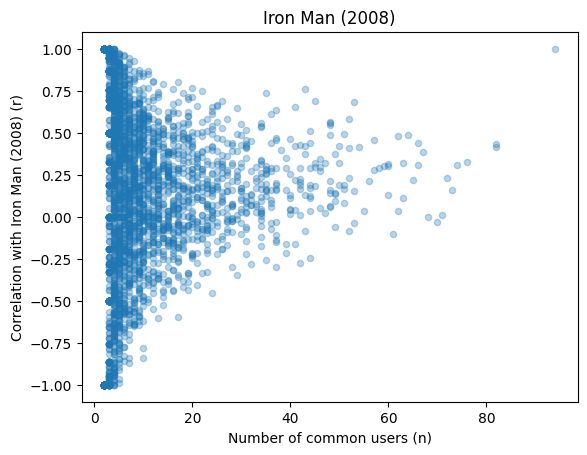

In [18]:
film = 'Iron Man (2008)'
r = movie_user.corrwith(movie_user[film]) # calculate r for Iron Man and other movies
n = movie_user[movie_user[film].notna()].notna().sum() # keep only users who rated IronMan and turn NaN into False
                                                       # then count True per col
                                                       # notna() on the whole table returns true if notNaN and False if NaN
tab = pd.DataFrame({'r': r, 'n': n}).dropna() # r and n have both movie titles as indices

print(tab.sort_values('r', ascending = False).head(10))
tab.plot.scatter(x = 'n', y = 'r', alpha = 0.3, title = film)
plt.xlabel('Number of common users (n)')
plt.ylabel('Correlation with ' + film + ' (r)')
plt.show()

We see that with small number of users, r varies a lot, while with more users r is less varing and approaches its true value.

### Confidence intervals for r (Fisher transformation)

$$z = \text{arctanh}(r), \qquad SE = \frac{1}{\sqrt{n-3}}, \qquad \text{95\% CI} = \left[\tanh(z - 1.96\cdot SE),\ \tanh(z + 1.96\cdot SE)\right]$$

The distribution of r is bounded and skewed, so the interval is computed for z (approximately normal) and transformed back with tanh. Its width depends only on n.

In [19]:
t = tab[(tab.n >= 5) & (tab.r.abs() < 1) & (tab.index != film)].copy()
# n >= 5: the formula needs n - 3 > 0; for n = 4 the interval is too wide
# |r| < 1: arctanh(+-1) is inf, and r = +-1 is coincidence eitherway because of the small n
# index != film: remove Iron Man

# Fisher transformation
z  = np.arctanh(t.r) # transforming r to z
se = 1 / np.sqrt(t.n - 3) # standard error for z, dependant only on n
t['lo'] = np.tanh(z - 1.96 * se) # lower boundary
t['hi'] = np.tanh(z + 1.96 * se) # upper boundary
t.sort_values('r', ascending=False).head(10)

,r,n,lo,hi
title,,,,
Working Girl (1988),0.975900,5,0.673628,0.998475
Man on Wire (2008),0.971297,5,0.622329,0.998180
Cheaper by the Dozen (2003),0.970725,5,0.616158,0.998144
Pain & Gain (2013),0.966130,5,0.568104,0.997847
American Splendor (2003),0.964526,6,0.704154,0.996251
"Day of the Doctor, The (2013)",0.960769,6,0.677352,0.995846
The Lobster (2015),0.952579,5,0.440616,0.996967
"Mexican, The (2001)",0.945108,7,0.666185,0.992081
Dawn of the Dead (2004),0.939336,5,0.333223,0.996095


In [20]:
genres = movies.drop_duplicates('title').set_index('title')['genres']

In [21]:
top_article = recc['title'].head(10)   # recommendations from the article
t.reindex(top_article)[['r', 'n', 'lo', 'hi']].join(genres)

,r,n,lo,hi,genres
title,,,,,
Avengers: Infinity War - Part I (2018),0.764922,11,0.304987,0.935526,Action|Adventure|Sci-Fi
Whiplash (2014),0.711657,20,0.392848,0.877755,Drama
Star Trek (2009),0.687861,45,0.494085,0.816531,Action|Adventure|Sci-Fi|IMAX
"Avengers, The (2012)",0.684344,53,0.508018,0.805621,Action|Adventure|Sci-Fi|IMAX
Ratatouille (2007),0.657183,41,0.438107,0.802570,Animation|Children|Drama
Terminator Salvation (2009),0.619493,16,0.178639,0.853197,Action|Adventure|Sci-Fi|Thriller
(500) Days of Summer (2009),0.611279,24,0.275914,0.813965,Comedy|Drama|Romance
X2: X-Men United (2003),0.609979,36,0.351974,0.781837,Action|Adventure|Sci-Fi|Thriller
X-Men (2000),0.583925,52,0.369979,0.739057,Action|Adventure|Sci-Fi


The article's top pick, Avengers: Infinity War, makes sense genre wise, but its correlation is based on only 11 common users with a 95% CI of [0.30, 0,94], so the evidence is weak. The same holds for Terminator Salvation (n = 16, CI [0.18, 0.85]). Star Trek and The Avengers are much more reliable.

Keeping only movies with at least 20 common users and ranking them by the lower CI bound will give better results.

In [22]:
t[t.n >= 20].sort_values('lo', ascending = False).head(10).join(genres)

,r,n,lo,hi,genres
title,,,,,
Iron Man 2 (2010),0.758589,43,0.593453,0.862439,Action|Adventure|Sci-Fi|Thriller|IMAX
X-Men: First Class (2011),0.738678,35,0.537819,0.860183,Action|Adventure|Sci-Fi|Thriller|War
"Avengers, The (2012)",0.684344,53,0.508018,0.805621,Action|Adventure|Sci-Fi|IMAX
Captain America: Civil War (2016),0.770032,20,0.496790,0.904382,Action|Sci-Fi|Thriller
Star Trek (2009),0.687861,45,0.494085,0.816531,Action|Adventure|Sci-Fi|IMAX
Ant-Man (2015),0.747608,22,0.476043,0.889006,Action|Adventure|Sci-Fi
Ratatouille (2007),0.657183,41,0.438107,0.802570,Animation|Children|Drama
X-Men: Days of Future Past (2014),0.691211,26,0.414956,0.850777,Action|Adventure|Sci-Fi
Slumdog Millionaire (2008),0.637293,37,0.394793,0.796783,Crime|Drama|Romance


We've got mostly Marvel/superhero movies (Iron Man 2, X-Men: First Class, The Avengers, Captain America: Civil War, Ant-Man), so the result makes more sense. Popular movies (like Ratatouille) still appear, because correlation measures similar rating patterns, not similar content.

Now we create a correct function for analysis.

In [23]:
def analyze_movie(film, min_n=20, top=10, plot=True):
    """Recommend movies correlated with `film`, ranked by the lower bound of the 95% CI."""
    genres = movies.drop_duplicates('title').set_index('title')['genres']
    min_n = max(min_n, 5) # for the confidence interval n - 3 > 0

    print(str(film) + ' genres: ' + str(genres[film]) + ' number of ratings: ' +
          str(movie_user[film].notna().sum()))

    # correlation with every other movie + number of common users
    r = movie_user.corrwith(movie_user[film])
    n = movie_user[movie_user[film].notna()].notna().sum()
    tab = pd.DataFrame({'r': r, 'n': n}).dropna()

    # keep reliable correlations only
    t = tab[(tab.n >= min_n) & (tab.r.abs() < 1) & (tab.index != film)].copy()
    print('Movies with at least ' + str(min_n) + ' common users: ' + str(len(t)))

    # 95% confidence interval (Fisher transformation)
    z  = np.arctanh(t.r)
    se = 1 / np.sqrt(t.n - 3)
    t['lo'] = np.tanh(z - 1.96 * se)
    t['hi'] = np.tanh(z + 1.96 * se)

    # rank by the lower bound and add genres
    return t.sort_values('lo', ascending=False).head(top).join(genres)

In [24]:
analyze_movie('Ant-Man (2015)')

Ant-Man (2015) genres: Action|Adventure|Sci-Fi number of ratings: 27


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Movies with at least 20 common users: 28


,r,n,lo,hi,genres
title,,,,,
Guardians of the Galaxy (2014),0.801587,25,0.594866,0.908856,Action|Adventure|Sci-Fi
Iron Man (2008),0.747608,22,0.476043,0.889006,Action|Adventure|Sci-Fi
Batman Begins (2005),0.690004,20,0.356258,0.867610,Action|Crime|IMAX
Avatar (2009),0.621533,23,0.281425,0.822911,Action|Adventure|Sci-Fi|IMAX
"Dark Knight, The (2008)",0.599131,26,0.275773,0.800671,Action|Crime|Drama|IMAX
Up (2009),0.593259,23,0.239658,0.807899,Adventure|Animation|Children|Drama
"Avengers, The (2012)",0.569491,23,0.205531,0.795060,Action|Adventure|Sci-Fi|IMAX
Iron Man 2 (2010),0.567064,21,0.179250,0.802345,Action|Adventure|Sci-Fi|Thriller|IMAX
"Lord of the Rings: The Two Towers, The (2002)",0.543932,21,0.146680,0.790101,Adventure|Fantasy


# WF3: EDA Pollution dataset: PM10 values in Lehen

# a) Missing values

In [25]:
chosen_col = 'PM10Lehen'

I will first determine the exact number of missing values and total number of records for the chosen column.

In [26]:
PM10Lehen_missing_vals = pollution_df[chosen_col].isna().sum()
PM10Lehen_total_num_of_vals = pollution_df[chosen_col].size
print('Missing values: ' + str(PM10Lehen_missing_vals))
print('Total values: ' + str(PM10Lehen_total_num_of_vals))

print('Per (%) of missing values: ' + str(PM10Lehen_missing_vals / PM10Lehen_total_num_of_vals * 100))

Missing values: 1046
Total values: 17520
Per (%) of missing values: 5.970319634703197


Note: 17520 = 365 * 24 * 2, which means that the data has been meassured every 0.5hour during a year.

Now I want to find pattern in the data. I will do this by displaying all NaNs from the column as a matrix. Purple spots represent a non-NaN meassurement, while yellow spots represent NaN meassurements. Each row is 0.5h, while each column is one day of the year.

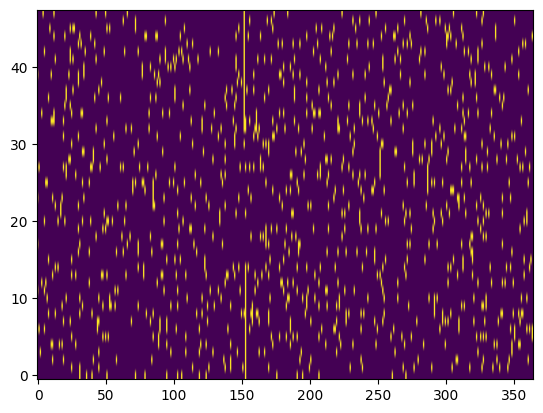

In [27]:
nans = pollution_df[chosen_col].isna().values.reshape(365, 48).T
plt.imshow(nans, aspect = 'auto', origin = 'lower') # aspect is a ratio between height and width of a one 
                                                    # cell, origin = lower -> record with 0 hours is on the bottom
plt.show()

There is no pattern in the missing hours, except for the straight line around the 150th day of the year. That line can be explained by some kind of technical issue.

The next useful thing to investigate is whether missing measurements tend to occur consecutively. I will create a graph showing the groups of consecutive missing measurements. The x-axis represents the size of each group (for example, an x value of 3 represents a group containing three consecutive missing measurements while the y-axis shows the number of such groups)

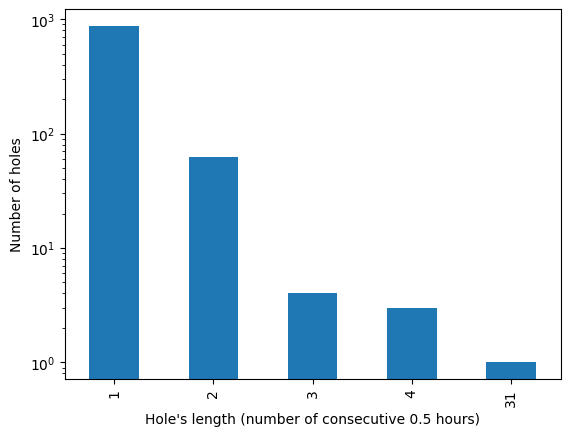

In [28]:
nans = pollution_df[chosen_col].isna()
groups = (nans != nans.shift()).cumsum()
lengths = nans.groupby(groups).sum()
lengths[lengths > 0].value_counts().sort_index().plot.bar(logy = True)
plt.xlabel('Hole\'s length (number of consecutive 0.5 hours)')
plt.ylabel('Number of holes')
plt.show()

# example:
# nans =               T F F T F T T T T F F F T T F
# nans.shift =         / T F F T F T T T T F F F T T
# nans != nans.shift = T T F T T T F F F T F F T F T
# .cumsum() =          1 2 2 3 4 5 5 5 5 6 6 6 7 7 8
# lengths =            1 0 0 1 0 4 4 4 4 0 0 0 2 2 0 # for each block count the number of T values

# 1 -> 2
# 4 -> 1
# 2 -> 1

We can see that a lot of NaN meassurements are not followed by other consecutive NaN meassurements. That means there is no pattern that could be explained by the sensor dying in a specific time of day for multiple 0.5hours.

Conclusion: About 6% of values are missing. Most gaps are single half-hours scattered randomly over days and time, plus one larger gap around 150th day. We must not drop the rows, because the time of each measurement is given only by its own position. Dropping rows would shift all days and hours. Short gaps can be interpolated.

# b) Unnormal values

Now we want to check if there are any unnormal values or outliers in the PM10 data. Boxplots are useful for discovering potential outliers, so I use them. I'll follow it up with line plot to get better understanding of their position.

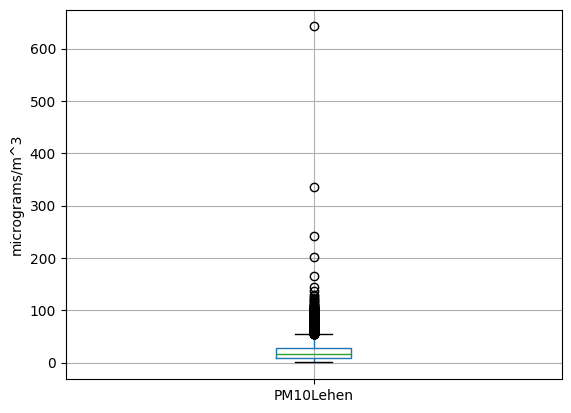

Upper whisker in micrograms/m^3: 54.9
Number of outliers: 738


In [29]:
bp_graph = pollution_df.boxplot(column = chosen_col, return_type = "dict")
plt.ylabel('micrograms/m^3')
plt.show()

upper_whisker = bp_graph["whiskers"][1].get_ydata()[1]
outliers = bp_graph["fliers"][0].get_ydata()

print('Upper whisker in micrograms/m^3: ' + str(upper_whisker))
print('Number of outliers: ' + str(len(outliers)))

#pollution_df.boxplot(column = chosen_col)
#plt.yscale('log')
#plt.show()

This graph shows us the presence of outliers, but it's hard to draw more conclusions by just this single graph.

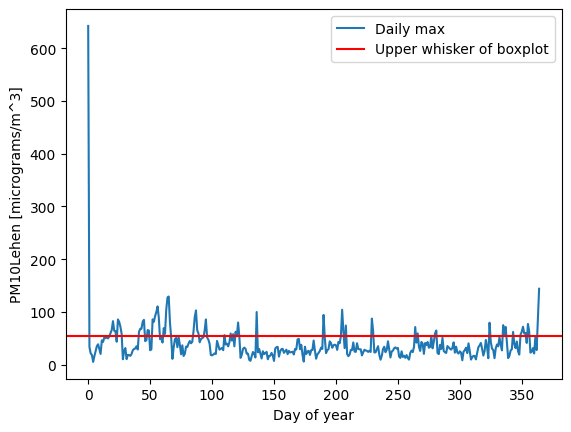

In [30]:
pollution_df[chosen_col].groupby(np.arange(len(pollution_df)) // 48).max().plot(label = 'Daily max')
plt.axhline(upper_whisker, color = 'red', label = 'Upper whisker of boxplot')
plt.xlabel('Day of year')
plt.ylabel(chosen_col + ' [micrograms/m^3]')
plt.legend()
plt.show()

The most extreme values appear in the first hours of the year and drop quickly afterwards, with another rise on the last day of the year. This might be caused by New Year's Eve fireworks.

# c) Distribution

Now I want to plot distribution. For this purpose I will create the density plot.

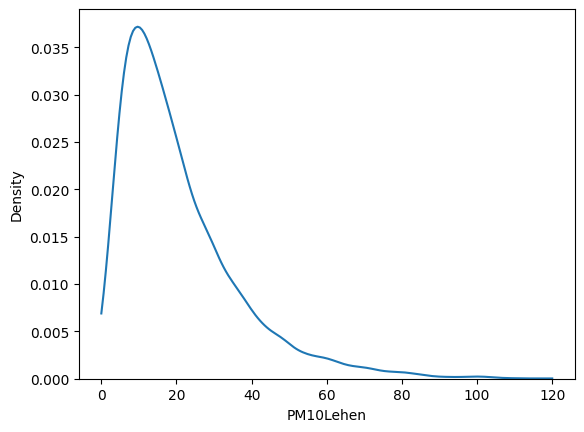

In [31]:
sb.kdeplot(pollution_df[chosen_col], clip = (0, 120)) # clip to limit the curve
plt.show()

In [32]:
values = pollution_df[chosen_col]

print('Basic distribution info:')
print('Mean: ', round(values.mean(), 1))
print('Median: ', round(values.median(), 1))
print('Std: ', round(values.std(), 1))
print('Min: ', round(values.min(), 1))
print('Max: ', round(values.max(), 1))

Basic distribution info:
Mean:  20.9
Median:  16.5
Std:  17.2
Min:  0.1
Max:  642.2


# d) The limit

Now I want to determine how many times did PM10 exceed the limit in the whole year. To do this I will plot a line plot with PM10Lehen daily means, then put a line representing yearly mean and the fixed limit.

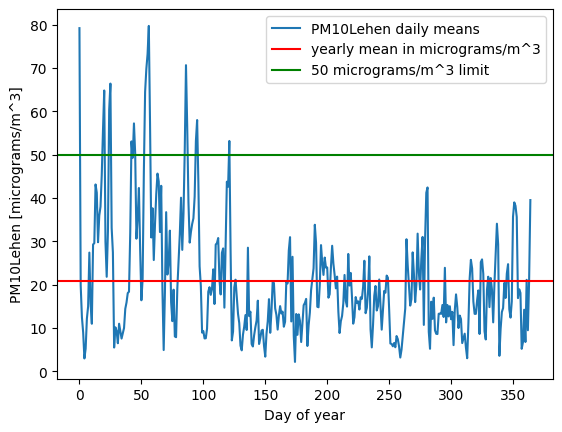

In [33]:
daily_mean_PM10Lehen = pollution_df[chosen_col].groupby(np.arange(len(pollution_df)) // 48).mean() # calculate mean for days
yearl_mean = pollution_df[chosen_col].mean()

daily_mean_PM10Lehen.plot(label = 'PM10Lehen daily means')
plt.axhline(yearl_mean, color = 'red', label = 'yearly mean in micrograms/m^3')
plt.axhline(50, color = 'green', label = '50 micrograms/m^3 limit')
plt.xlabel('Day of year')
plt.ylabel(chosen_col + ' [micrograms/m^3]')
plt.legend()
plt.show()

In [34]:
total_above_limit = (daily_mean_PM10Lehen > 50).sum()
print('Total PM10Lehen daily means above the limit of 50 micrograms/m^3: ' + str(total_above_limit))
print('Yearly PM10Lehen mean in micrograms/m^3: ' + str(yearl_mean))

Total PM10Lehen daily means above the limit of 50 micrograms/m^3: 19
Yearly PM10Lehen mean in micrograms/m^3: 20.874948403544977


The daily mean exceeded 50 micrograms/m^3 on 19 days. That is fewer than any of the allowed numbers of exceedances (35, 30 or 25 per year), and the annual mean of 20.9 micrograms/m^3 is below 40 micrograms/m^3, so the limits are met. The best standard plot is a line plot of daily means with the limit drawn as a horizontal line. Aggregating to days avoids the 'too many points' problem of the raw half-hourly series.

# e) Relationship with the following variables

To explore dependency between two numerical variables, I'll use scatterplot.

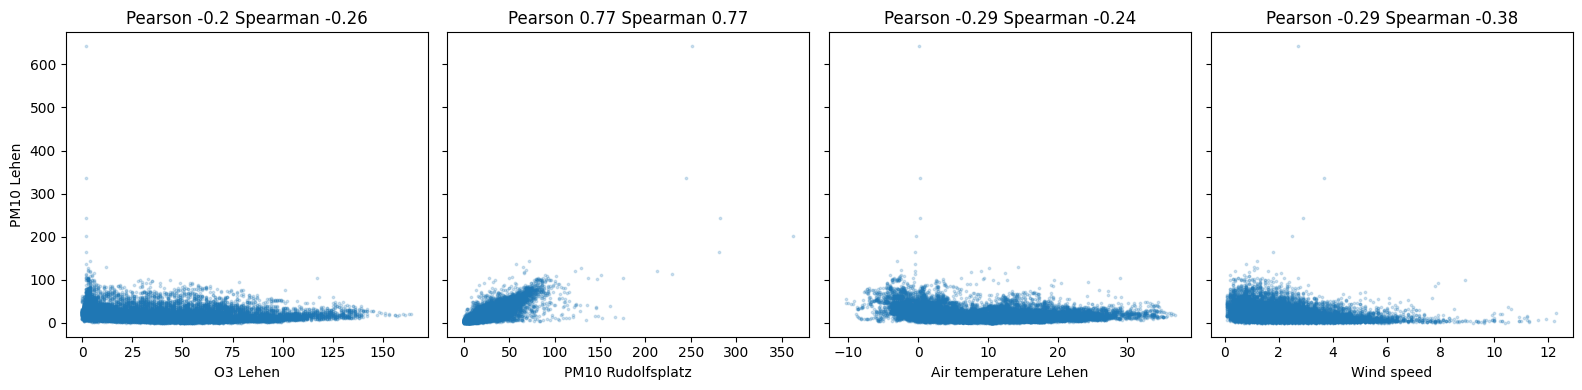

In [35]:
others = ['O3Lehen', 'PM10Rud', 'LTLehen', 'WG']
labels = ['O3 Lehen', 'PM10 Rudolfsplatz', 'Air temperature Lehen', 'Wind speed']

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for ax, col, label in zip(axes, others, labels):
    ax.scatter(pollution_df[col], pollution_df[chosen_col], s = 3, alpha = 0.2)
    pearson = pollution_df[col].corr(pollution_df[chosen_col])
    spearman = pollution_df[col].corr(pollution_df[chosen_col], method = 'spearman')
    ax.set_title('Pearson ' + str(round(pearson, 2)) + ' Spearman ' + str(round(spearman, 2)))
    ax.set_xlabel(label)
axes[0].set_ylabel('PM10 Lehen')
plt.tight_layout()
plt.show()

For O3 there is a non-linear L shaped relationship. For PM10 Rudolfsplatz there is a linear relationship which is confirmed by both Pearson and Spearman. For Air temperature there is a weak non linear relationship where high PM10 values appear only on low temperatures. For wind speed there is a similar non-linear relationship as with O3.

# f) Does it change through the day?

Hour of day is a discrete numerical variable. Despite that, I decided to use grouped boxplots to discover the dependencies.

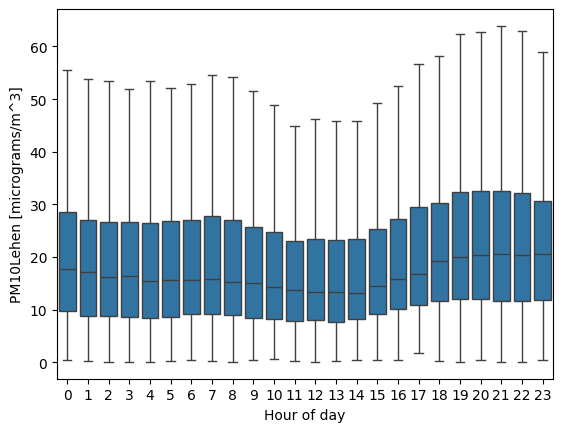

In [36]:
row = np.arange(len(pollution_df))
pollution_df['hour'] = (row % 48) // 2
plt.xlabel('Hour of day')
plt.ylabel(chosen_col + ' [micrograms/m^3]')
sb.boxplot(data = pollution_df, x = 'hour', y = chosen_col, showfliers = False)
plt.show()

We can draw conclusions that PM10 is the lowest during the middle of the day, and the highest around 22 - 23.

# WF4: EDA Pollution dataset: ozone O3. Answer the following questions using proper graphics

# a) Missing values

In [37]:
chosen_col = 'O3Lehen'

I will first determine the exact number of missing values and total number of records for the chosen column.

In [38]:
O3Lehen_missing_vals = pollution_df[chosen_col].isna().sum()
O3Lehen_total_num_of_vals = pollution_df[chosen_col].size
print('Missing values: ' + str(O3Lehen_missing_vals))
print('Total values: ' + str(O3Lehen_total_num_of_vals))

print('Per (%) of missing values: ' + str(O3Lehen_missing_vals / O3Lehen_total_num_of_vals * 100))

Missing values: 644
Total values: 17520
Per (%) of missing values: 3.6757990867579906


Note: 17520 = 365 * 24 * 2, which means that the data has been meassured every half an hour during a year.

Now I want to find pattern in the data. I will do this by displaying all NaNs from the column as a matrix. Purple spots represent a non-NaN meassurement, while yellow spots represent NaN meassurements. Each row is 0.5h, while each column is one day of the year.

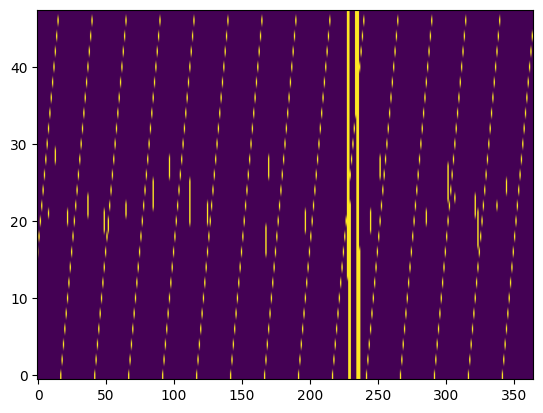

In [39]:
nans = pollution_df[chosen_col].isna().values.reshape(365, 48).T
plt.imshow(nans, aspect = 'auto', origin = 'lower')
plt.show()

I will zoom in to better analyize the graph.

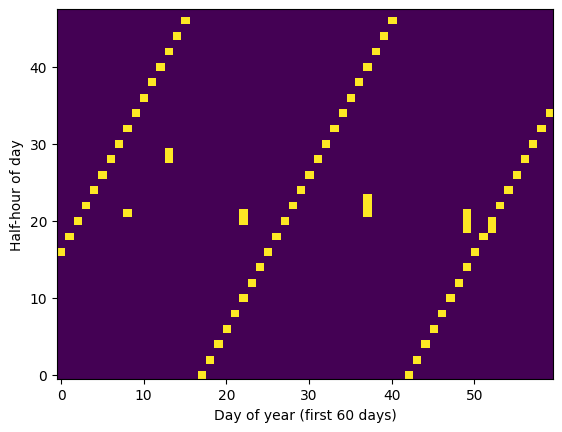

In [40]:
plt.imshow(nans[:, :60], aspect = "auto", origin = "lower")
plt.xlabel("Day of year (first 60 days)")
plt.ylabel("Half-hour of day")
plt.show()

We can see that there is a pattern. The sensor is probably making some kind of checkup or synch every 25 hours.

The next useful thing to investigate is whether missing measurements tend to occur consecutively. I will create a graph showing the groups of consecutive missing measurements. The x-axis represents the size of each group (for example, an x value of 3 represents a group containing three consecutive missing measurements while the y-axis shows the number of such groups)

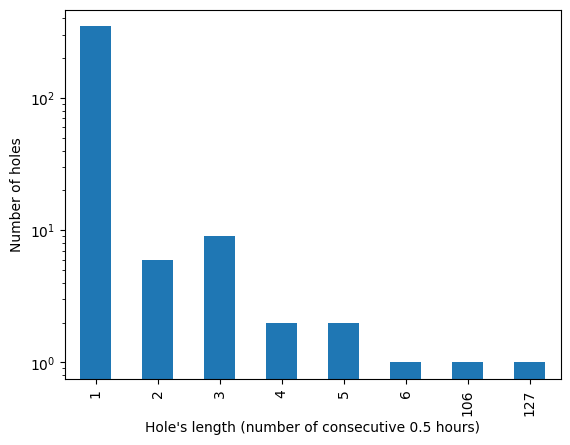

In [41]:
nans = pollution_df[chosen_col].isna()
groups = (nans != nans.shift()).cumsum()
lengths = nans.groupby(groups).sum()
lengths[lengths > 0].value_counts().sort_index().plot.bar(logy = True)
plt.xlabel('Hole\'s length (number of consecutive 0.5 hours)')
plt.ylabel('Number of holes')
plt.show()

# example:
# nans =               T F F T F T T T T F F F T T F
# nans.shift =         / T F F T F T T T T F F F T T
# nans != nans.shift = T T F T T T F F F T F F T F T
# .cumsum() =          1 2 2 3 4 5 5 5 5 6 6 6 7 7 8
# lengths =            1 0 0 1 0 4 4 4 4 0 0 0 2 2 0 # for each block count the number of T values

# 1 -> 2
# 4 -> 1
# 2 -> 1

We can also observe two very large holes with consecutive NaNs. This marks that the sensor probably wasn't working during that period.

Conclusion: About 3.7% of values are missing. We notice the 25 hour pattern between the missing entries. For similar reasons we can't drop the records with missing entries. We must consider that because of the two large holes in the measurement, we might underestimate the number of exceedances.

# b) Unnormal values

Now we want to check if there are any unnormal values or outliers in the O3 data. Boxplots are useful for discovering potential outliers, so I use them. I'll follow it up with line plot to get better understanding of their position.

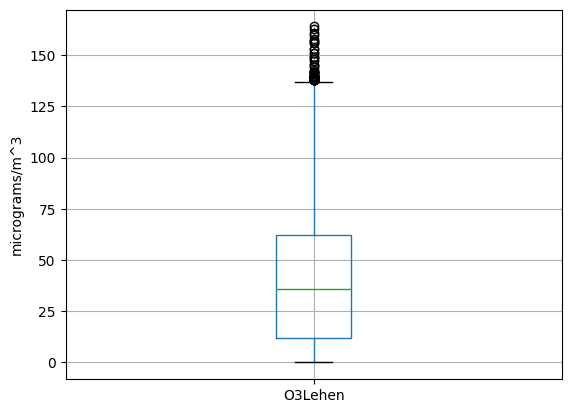

Upper whisker in micrograms/m^3: 137.0
Number of outliers: 54


In [42]:
bp_graph = pollution_df.boxplot(column = chosen_col, return_type = "dict")
plt.ylabel('micrograms/m^3')
plt.show()

upper_whisker = bp_graph["whiskers"][1].get_ydata()[1]
outliers = bp_graph["fliers"][0].get_ydata()

print('Upper whisker in micrograms/m^3: ' + str(upper_whisker))
print('Number of outliers: ' + str(len(outliers)))

#pollution_df.boxplot(column = chosen_col)
#plt.yscale('log')
#plt.show()

We can observe multiple potential outliers. Additionally, there are less outliers than with the PM10.

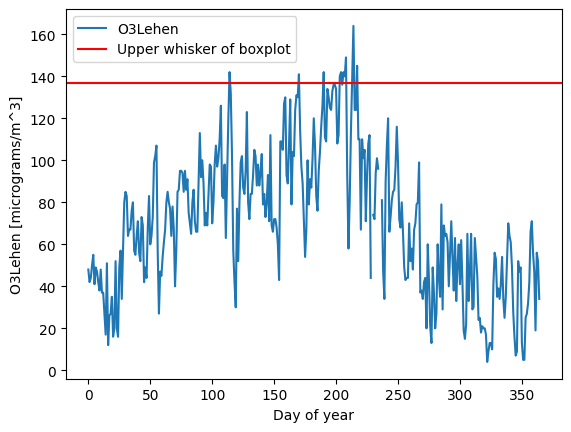

In [43]:
pollution_df[chosen_col].groupby(np.arange(len(pollution_df)) // 48).max().plot()
plt.axhline(upper_whisker, color = 'red', label = 'Upper whisker of boxplot')
plt.xlabel('Day of year')
plt.ylabel(chosen_col + ' [micrograms/m^3]')
plt.legend()
plt.show()

With the upper whisker drawn as a line, we can see when the boxplot outliers occur. All days above it lie in spring and summer, and the daily maximum show a clear seasonal pattern. O3 is high in summer and low in winter. Ozone forms in strong sunlight, so these outliers are expected summer peaks, not measurement errors.

# c) Distribution

Now I want to plot distribution. For this purpose I will create the density plot.

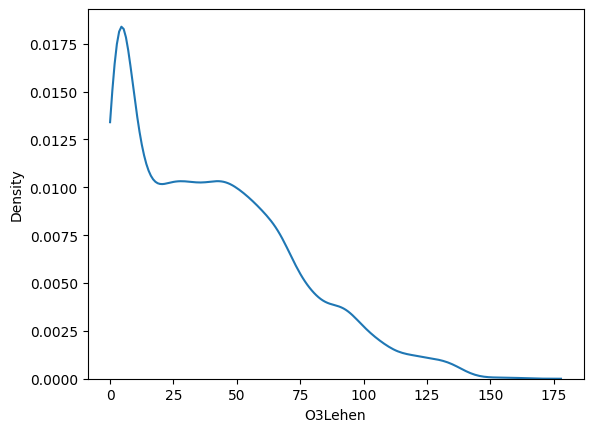

In [44]:
sb.kdeplot(pollution_df[chosen_col], clip=(0, None))
plt.show()

In [45]:
values = pollution_df[chosen_col]

print('Basic distribution info:')
print('Mean: ', round(values.mean(), 1))
print('Median: ', round(values.median(), 1))
print('Std: ', round(values.std(), 1))
print('Min: ', round(values.min(), 1))
print('Max: ', round(values.max(), 1))

Basic distribution info:
Mean:  40.8
Median:  36.0
Std:  32.4
Min:  0.0
Max:  164.0


# d) The Limit

Now I want to determine how many times did O3 exceed the limit in the whole year. To do this I will plot a line plot with O3 daily means, then put a line representing yearly mean and the fixed limit.

Note: The EU ozone target is defined using an 8 hour running mean, not hourly values or the daily mean. The 120 micrograms/m^3 limit applies to the maximum daily 8 hour running mean, and that's what rolling(8) computes.

Days with 8 hour mean > 120: 20


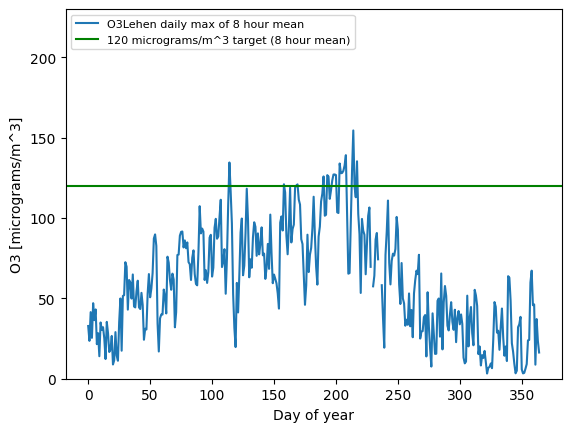

In [46]:
# calculates hourly averages (merges two consecutive 0.5hour meassurements)
# then calculates the mean
hourly_mean_O3 = pollution_df[chosen_col].groupby(np.arange(len(pollution_df)) // 2).mean()

day_of_hour = np.arange(len(hourly_mean_O3)) // 24 # determines which hour belong to which day

# highest 1 hour mean of each day
daily_max_hourly_O3 = hourly_mean_O3.groupby(day_of_hour).max()

# for each hour calculate the mean of it and 7 hours before it
# then group by day and for each day take the maximum meassurement
daily_max_8h_O3 = hourly_mean_O3.rolling(8).mean().groupby(day_of_hour).max()

print('Days with 8 hour mean > 120:', (daily_max_8h_O3 > 120).sum())

daily_max_8h_O3.plot(label = 'O3Lehen daily max of 8 hour mean')
plt.axhline(120, color = 'green', label = '120 micrograms/m^3 target (8 hour mean)')
plt.ylim(0, 230)
plt.xlabel('Day of year')
plt.ylabel('O3 [micrograms/m^3]')
plt.legend(loc = 'upper left', fontsize = 8)
plt.show()

In [47]:
days_above_180 = (daily_max_hourly_O3 > 180).sum()
days_above_120 = (daily_max_8h_O3 > 120).sum()

#print('Days with O3Lehen 1 hour mean above 180 micrograms/m^3 (information threshold): ' + str(days_above_180))
print('Days with O3Lehen 8 hour mean above 120 micrograms/m^3 (target value): ' + str(days_above_120))
print('Highest O3Lehen 1 hour mean in micrograms/m^3: ' + str(round(daily_max_hourly_O3.max(), 1)))
print('Highest O3Lehen 8 hour mean in micrograms/m^3: ' + str(round(daily_max_8h_O3.max(), 1)))

Days with O3Lehen 8 hour mean above 120 micrograms/m^3 (target value): 20
Highest O3Lehen 1 hour mean in micrograms/m^3: 162.5
Highest O3Lehen 8 hour mean in micrograms/m^3: 154.5


The maximum daily 8 hour mean exceeded 120 micrograms/m^3 on 20 days. Because of the two long gaps in August, the true number of exceedance days may be slightly higher. The best standard plot is again a line plot of the daily values with the threshold line.

# e) Relationship with the following variables

To explore dependency between two numerical variables, I'll use scatterplot.

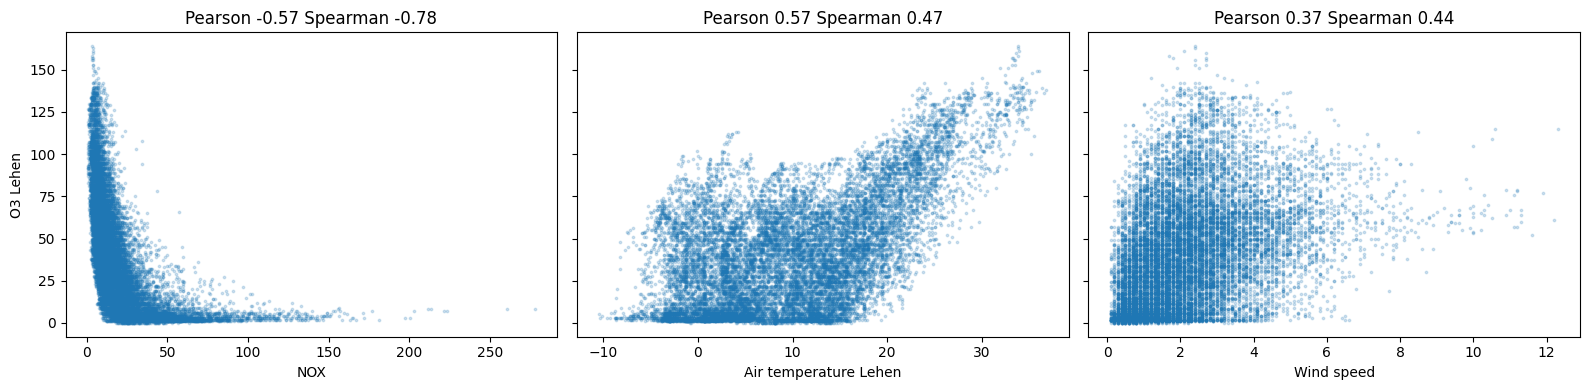

In [48]:
others = ['NOXLehen', 'LTLehen', 'WG']
labels = ['NOX', 'Air temperature Lehen', 'Wind speed']

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, col, label in zip(axes, others, labels):
    ax.scatter(pollution_df[col], pollution_df[chosen_col], s = 3, alpha = 0.2)
    pearson = pollution_df[col].corr(pollution_df[chosen_col])
    spearman = pollution_df[col].corr(pollution_df[chosen_col], method = 'spearman')
    ax.set_title('Pearson ' + str(round(pearson, 2)) + ' Spearman ' + str(round(spearman, 2)))
    ax.set_xlabel(label)
axes[0].set_ylabel('O3 Lehen')
plt.tight_layout()
plt.show()

For Nox we can obsever a strong nonlinear relationship (lower NOX, higher O3). For Air temp. we can observe something that looks like a linear relationship but not quite. Higher temperature can represent summer when there is more sunlight. For wind speed we observer nonlinear relationship. With weak winds, value can be anything, while with stronger winds value of O3 is something high.

# f) Does it change through the day?

Hour of day is a discrete numerical variable. Despite that, I decided to use grouped boxplots to discover the dependencies.

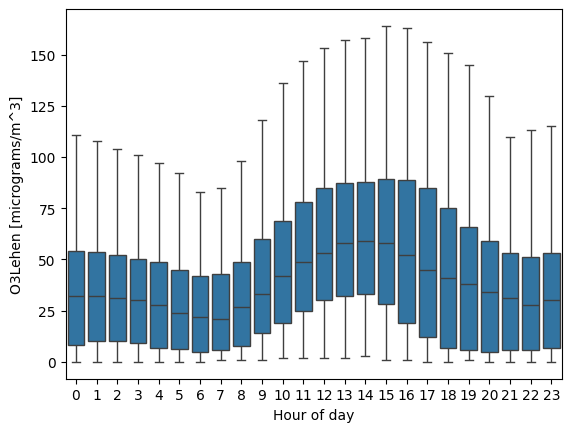

In [49]:
row = np.arange(len(pollution_df))
pollution_df['hour'] = (row % 48) // 2
plt.xlabel('Hour of day')
plt.ylabel(chosen_col + ' [micrograms/m^3]')
sb.boxplot(data = pollution_df, x = 'hour', y = chosen_col, showfliers = False)
plt.show()

We can observer that the O3 varies throughout the day. It is at its highest between 13 and 15.

**Declaration of AI use**

**AI system:** Claude (Anthropic), model Claude Opus 5.5, used via the Claude app (claude.ai), October 2026.

**Type and extent of use:** The AI was used as a tutor and assistant throughout the exercise:

- **Understanding the task and concepts:** explanations of the article's analysis, Pearson correlation, how pandas functions work (`corrwith`, `notna`, `groupby`, `rolling`, `join`, `reindex`), etc.
- **Code:** suggested code that I adapted and used
- **Debugging:** finding the cause of errors (e.g. wrong file loaded, `KeyError`).
- **Interpretation and text:** suggested wording for several markdown explanations and conclusions (WF2 conclusions, missing values, outliers, limits, distributions), which I checked against my own results and adapted.
- **Review:** checked my notebook against the task sheet and lecture slides and pointed out missing answers, inconsistencies and spelling mistakes.